In [2]:
import zipfile
import os

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/share_market_data")

print("Dataset extracted successfully!")
print(os.listdir("/content/share_market_data"))

Dataset extracted successfully!
['getSandP.py', 'merge.sh', 'individual_stocks_5yr', 'all_stocks_5yr.csv']


In [3]:
import pandas as pd
import os

data_path = "/content/share_market_data"

for root, dirs, files in os.walk(data_path):
    for file in files:
        print(os.path.join(root, file))

/content/share_market_data/getSandP.py
/content/share_market_data/merge.sh
/content/share_market_data/all_stocks_5yr.csv
/content/share_market_data/individual_stocks_5yr/individual_stocks_5yr/PG_data.csv
/content/share_market_data/individual_stocks_5yr/individual_stocks_5yr/WLTW_data.csv
/content/share_market_data/individual_stocks_5yr/individual_stocks_5yr/BA_data.csv
/content/share_market_data/individual_stocks_5yr/individual_stocks_5yr/LEG_data.csv
/content/share_market_data/individual_stocks_5yr/individual_stocks_5yr/ADBE_data.csv
/content/share_market_data/individual_stocks_5yr/individual_stocks_5yr/AME_data.csv
/content/share_market_data/individual_stocks_5yr/individual_stocks_5yr/GLW_data.csv
/content/share_market_data/individual_stocks_5yr/individual_stocks_5yr/VRSK_data.csv
/content/share_market_data/individual_stocks_5yr/individual_stocks_5yr/NCLH_data.csv
/content/share_market_data/individual_stocks_5yr/individual_stocks_5yr/ACN_data.csv
/content/share_market_data/individual

In [4]:
import pandas as pd

file_path = "/content/share_market_data/all_stocks_5yr.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Number of rows: 619040
Number of columns: 7


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [5]:
# Basic information about the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (619040, 7)

Column Names:
['date', 'open', 'high', 'low', 'close', 'volume', 'Name']

Data Types:
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
Name       object
dtype: object

Missing Values:
date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64


In [6]:
# Basic statistical summary

df.describe()

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [7]:
# Number of different companies

print("Number of companies:", df["Name"].nunique())

print("\nSome company names:")
print(df["Name"].unique()[:20])

Number of companies: 505

Some company names:
['AAL' 'AAPL' 'AAP' 'ABBV' 'ABC' 'ABT' 'ACN' 'ADBE' 'ADI' 'ADM' 'ADP'
 'ADSK' 'ADS' 'AEE' 'AEP' 'AES' 'AET' 'AFL' 'AGN' 'AIG']


In [8]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort by company and date
df = df.sort_values(["Name", "date"]).reset_index(drop=True)

# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing Open, High and Low values
df[["open", "high", "low"]] = df[["open", "high", "low"]].ffill()

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDataset shape after cleaning:", df.shape)

Missing values before cleaning:
date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

Missing values after cleaning:
date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

Dataset shape after cleaning: (619040, 7)


In [9]:
# Select Apple stock data
aapl = df[df["Name"] == "AAPL"].copy()

print("AAPL records:", len(aapl))
print("\nDate range:")
print(aapl["date"].min(), "to", aapl["date"].max())

aapl.head()

AAPL records: 1259

Date range:
2013-02-08 00:00:00 to 2018-02-07 00:00:00


,date,open,high,low,close,volume,Name
3777,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
3778,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
3779,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3780,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
3781,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


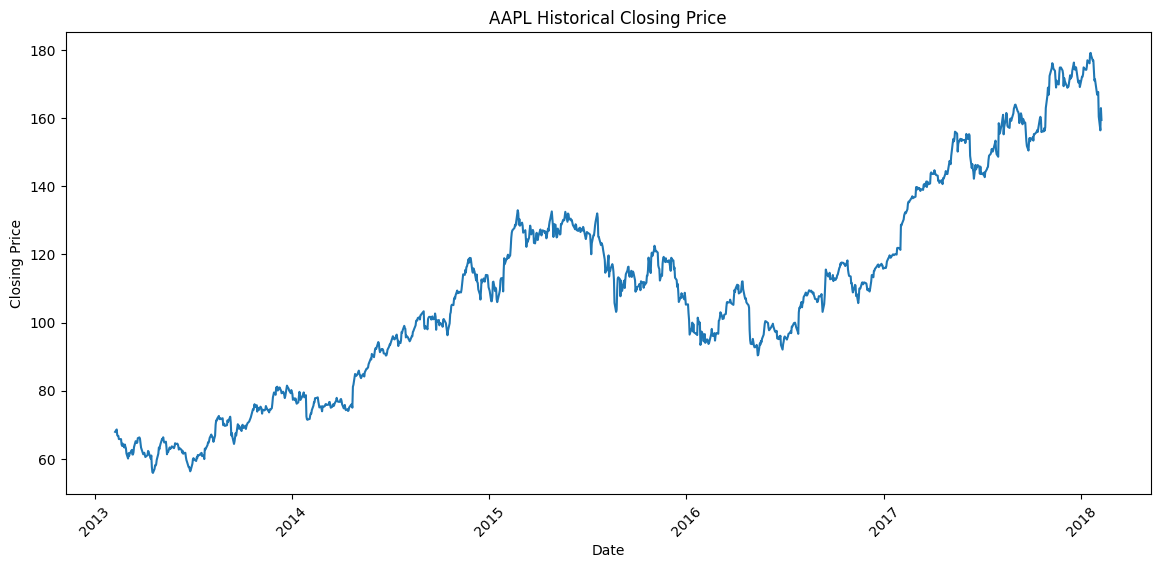

In [10]:
# Plot AAPL closing price

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(aapl["date"], aapl["close"])

plt.title("AAPL Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)

plt.show()

In [11]:
# Step 9: Prepare AAPL data for LSTM

import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Use only the closing price
prices = aapl[["close"]].values

print("Total price records:", len(prices))

# Scale prices between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

# Create sequences
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_prices)):
    X.append(scaled_prices[i-sequence_length:i, 0])
    y.append(scaled_prices[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape for LSTM
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

Total price records: 1259
X shape: (1199, 60, 1)
y shape: (1199,)


In [12]:
# Step 10: Train-Test Split

train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training samples: 959
Testing samples: 240

Training shape: (959, 60, 1)
Testing shape: (240, 60, 1)


In [14]:
# Step 11: Build LSTM Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

model = Sequential([
    Input(shape=(X_train.shape[1], 1)),

    LSTM(50, return_sequences=True),
    Dropout(0.2),

    LSTM(50, return_sequences=False),
    Dropout(0.2),

    Dense(25),
    Dense(1)
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Display model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Step 12: Train the LSTM Model

history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0122 - val_loss: 0.0113
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0031 - val_loss: 0.0017
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0024 - val_loss: 0.0014
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0020 - val_loss: 0.0014
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0017 - val_loss: 0.0022
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0015 - val_loss: 0.0017
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0015 - val_loss: 9.4097e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0014 - val_loss: 0.0027
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss:

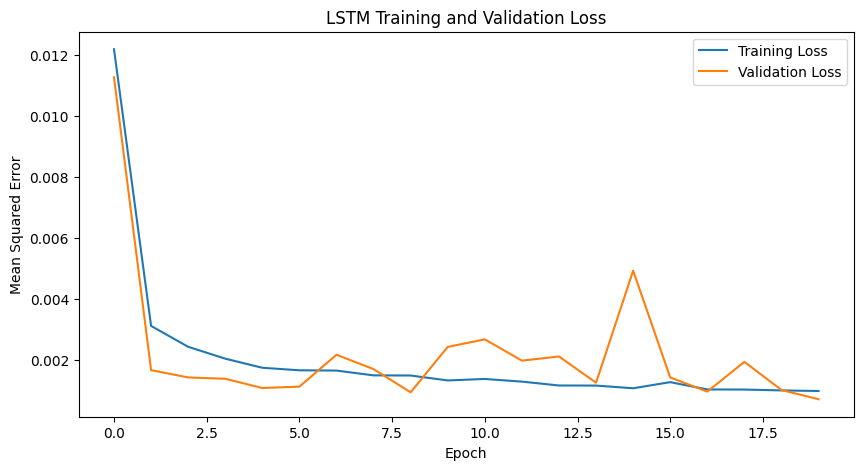

In [16]:
# Step 13: Training and Validation Loss

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()

plt.show()

In [17]:
# Step 14: Make Predictions

predictions = model.predict(X_test)

# Convert predictions back to original price scale
predictions = scaler.inverse_transform(predictions)

# Convert actual values back to original price scale
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Predictions shape:", predictions.shape)
print("Actual values shape:", actual_prices.shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step
Predictions shape: (240, 1)
Actual values shape: (240, 1)


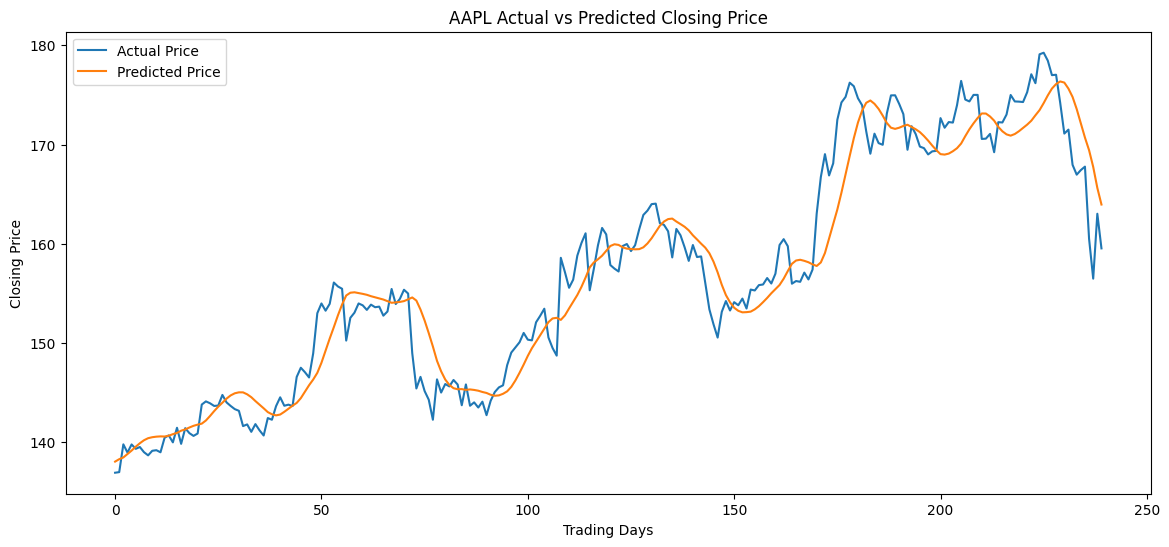

In [18]:
# Step 15: Actual vs Predicted Prices

plt.figure(figsize=(14, 6))

plt.plot(actual_prices, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("AAPL Actual vs Predicted Closing Price")
plt.xlabel("Trading Days")
plt.ylabel("Closing Price")
plt.legend()

plt.show()

In [19]:
# Step 16: Evaluate the LSTM Model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(actual_prices, predictions)

mse = mean_squared_error(actual_prices, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(actual_prices, predictions)

print("Model Evaluation Results")
print("------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Model Evaluation Results
------------------------
MAE  : 2.5331
MSE  : 10.8840
RMSE : 3.2991
R²   : 0.9198


In [20]:
# Step 17: Feature Engineering for Anomaly Detection

aapl["daily_return"] = aapl["close"].pct_change() * 100

aapl["volume_change"] = aapl["volume"].pct_change() * 100

aapl["volatility"] = aapl["daily_return"].rolling(window=20).std()

# Remove rows created by rolling calculations
aapl_features = aapl.dropna().copy()

print("Feature engineering completed!")

print("\nNew features:")
print(aapl_features[
    ["date", "close", "volume", "daily_return",
     "volume_change", "volatility"]
].head())

Feature engineering completed!

New features:
           date    close     volume  daily_return  volume_change  volatility
3797 2013-03-11  62.5528  118272126      1.424583      20.865362    1.524649
3798 2013-03-12  61.2042  116268341     -2.155939      -1.694216    1.533680
3799 2013-03-13  61.1928  101369051     -0.018626     -12.814572    1.466456
3800 2013-03-14  61.7857   75834906      0.968905     -25.189291    1.498990
3801 2013-03-15  63.3799  160710606      2.580209     111.921679    1.637940


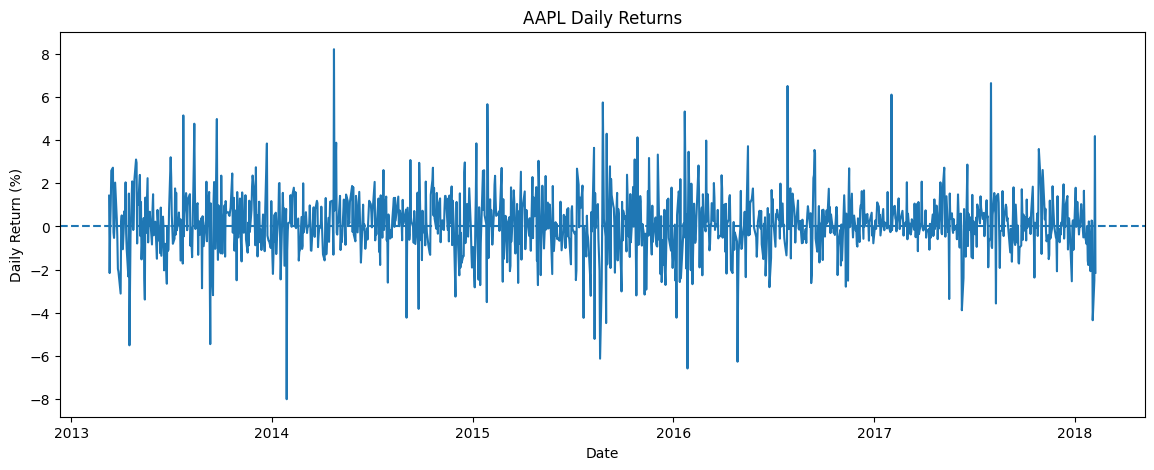

In [21]:
# Step 18: Visualize Daily Returns

plt.figure(figsize=(14, 5))

plt.plot(
    aapl_features["date"],
    aapl_features["daily_return"]
)

plt.axhline(0, linestyle="--")

plt.title("AAPL Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

plt.show()

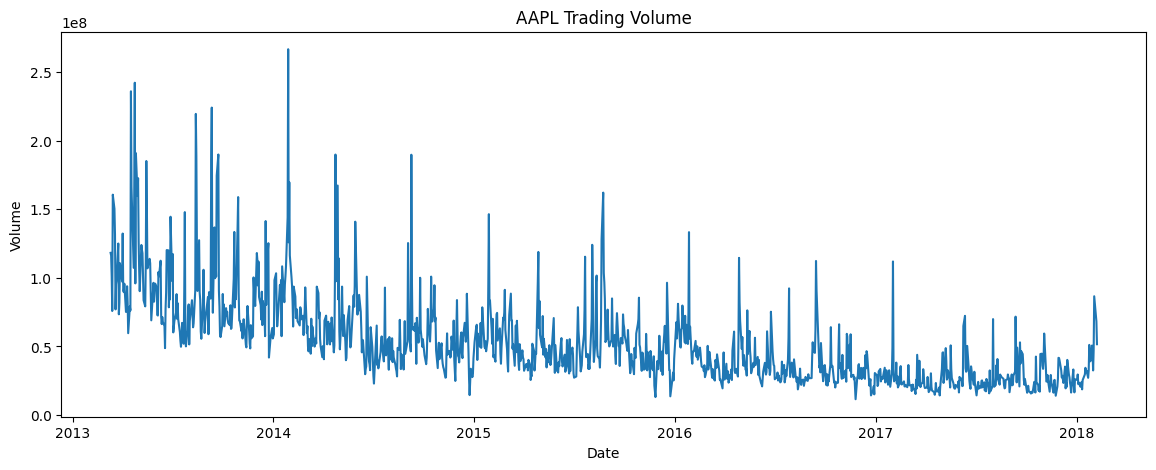

In [22]:
# Step 19: Visualize Trading Volume

plt.figure(figsize=(14, 5))

plt.plot(
    aapl_features["date"],
    aapl_features["volume"]
)

plt.title("AAPL Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

In [23]:
# Step 20: Detect Potential Suspicious Market Activity

# Calculate thresholds using the 95th percentile
return_threshold = aapl_features["daily_return"].abs().quantile(0.95)
volume_threshold = aapl_features["volume"].quantile(0.95)

print("Return threshold:", round(return_threshold, 2), "%")
print("Volume threshold:", int(volume_threshold))

# Flag potential anomalies
aapl_features["anomaly"] = (
    (aapl_features["daily_return"].abs() > return_threshold) &
    (aapl_features["volume"] > volume_threshold)
).astype(int)

print("\nPotential anomalous days:", aapl_features["anomaly"].sum())
print("Normal days:", (aapl_features["anomaly"] == 0).sum())

Return threshold: 2.87 %
Volume threshold: 112841865

Potential anomalous days: 20
Normal days: 1219


In [24]:
# Step 21: Display Potential Anomalies

anomalies = aapl_features[aapl_features["anomaly"] == 1]

print("Potential anomalous market activity:")
display(
    anomalies[
        [
            "date",
            "close",
            "volume",
            "daily_return",
            "volume_change",
            "volatility",
            "anomaly"
        ]
    ]
)

Potential anomalous market activity:


,date,close,volume,daily_return,volume_change,volatility,anomaly
3823,2013-04-17,57.5428,236138966,-5.499299,209.803902,1.806423,1
3831,2013-04-29,61.4457,159958876,3.095601,-16.254542,2.001261,1
3832,2013-04-30,63.2542,172737600,2.943249,7.988756,2.104618,1
3843,2013-05-15,61.2642,185278968,-3.381723,65.950498,1.885066,1
3891,2013-07-24,62.9299,147978789,5.136019,62.502802,1.677603,1
3905,2013-08-13,69.9385,219634975,4.752298,141.334634,1.871998,1
3925,2013-09-11,66.8156,224250866,-5.444449,20.893582,1.751750,1
3928,2013-09-16,64.3028,136823442,-3.179139,83.461323,1.826712,1
3933,2013-09-23,70.0914,190021706,4.969988,8.850703,2.292127,1
3997,2013-12-23,81.4413,125326831,3.837621,14.869739,1.449153,1


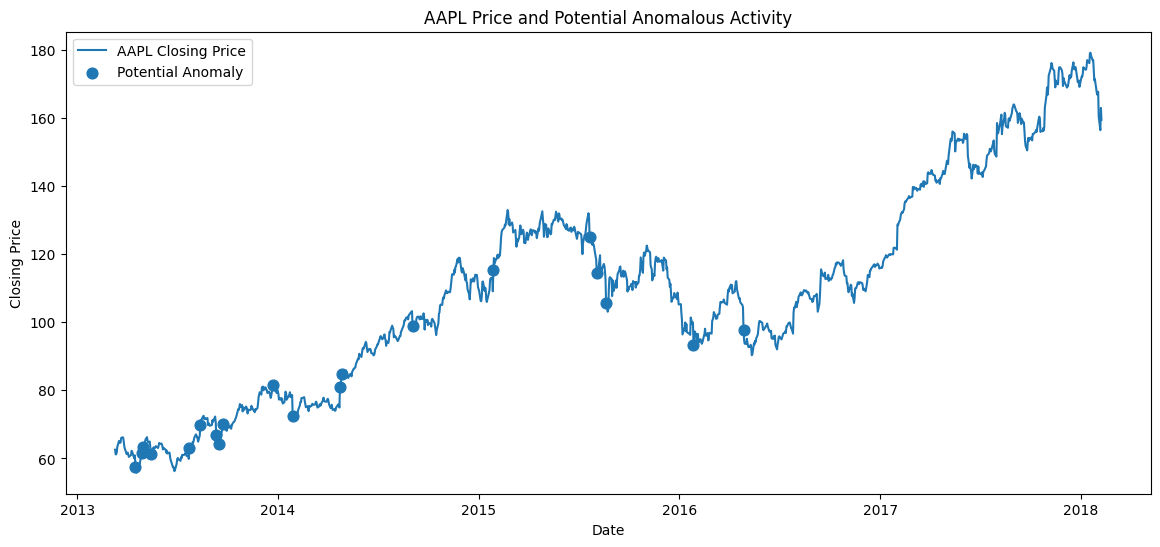

In [25]:
# Step 22: Visualize Potential Anomalies

plt.figure(figsize=(14, 6))

plt.plot(
    aapl_features["date"],
    aapl_features["close"],
    label="AAPL Closing Price"
)

plt.scatter(
    anomalies["date"],
    anomalies["close"],
    marker="o",
    s=60,
    label="Potential Anomaly"
)

plt.title("AAPL Price and Potential Anomalous Activity")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.show()

In [26]:
# Step 23: Anomaly Summary

anomaly_summary = anomalies[
    [
        "date",
        "close",
        "volume",
        "daily_return",
        "volume_change",
        "volatility"
    ]
].copy()

print("Number of potential anomalies:", len(anomaly_summary))

display(anomaly_summary)

Number of potential anomalies: 20


,date,close,volume,daily_return,volume_change,volatility
3823,2013-04-17,57.5428,236138966,-5.499299,209.803902,1.806423
3831,2013-04-29,61.4457,159958876,3.095601,-16.254542,2.001261
3832,2013-04-30,63.2542,172737600,2.943249,7.988756,2.104618
3843,2013-05-15,61.2642,185278968,-3.381723,65.950498,1.885066
3891,2013-07-24,62.9299,147978789,5.136019,62.502802,1.677603
3905,2013-08-13,69.9385,219634975,4.752298,141.334634,1.871998
3925,2013-09-11,66.8156,224250866,-5.444449,20.893582,1.751750
3928,2013-09-16,64.3028,136823442,-3.179139,83.461323,1.826712
3933,2013-09-23,70.0914,190021706,4.969988,8.850703,2.292127
3997,2013-12-23,81.4413,125326831,3.837621,14.869739,1.449153


In [27]:
# Percentage of days flagged as potential anomalies

anomaly_percentage = (
    len(anomalies) / len(aapl_features)
) * 100

print(
    f"Potential anomaly percentage: {anomaly_percentage:.2f}%"
)

Potential anomaly percentage: 1.61%


In [28]:
# Step 24: Save the trained LSTM model

model.save("/content/share_market_lstm_model.keras")

print("LSTM model saved successfully!")

LSTM model saved successfully!


In [29]:
# Step 25: Create results folder

import os

os.makedirs("/content/results", exist_ok=True)

print("Results folder created!")

Results folder created!


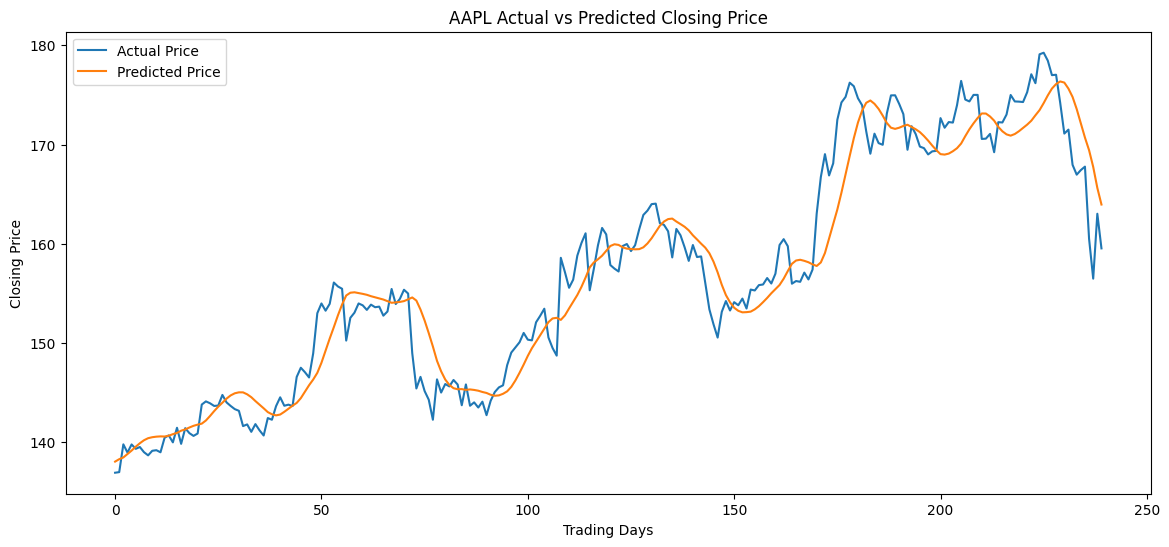

In [30]:
# Save Actual vs Predicted graph

plt.figure(figsize=(14, 6))

plt.plot(actual_prices, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("AAPL Actual vs Predicted Closing Price")
plt.xlabel("Trading Days")
plt.ylabel("Closing Price")
plt.legend()

plt.savefig(
    "/content/results/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

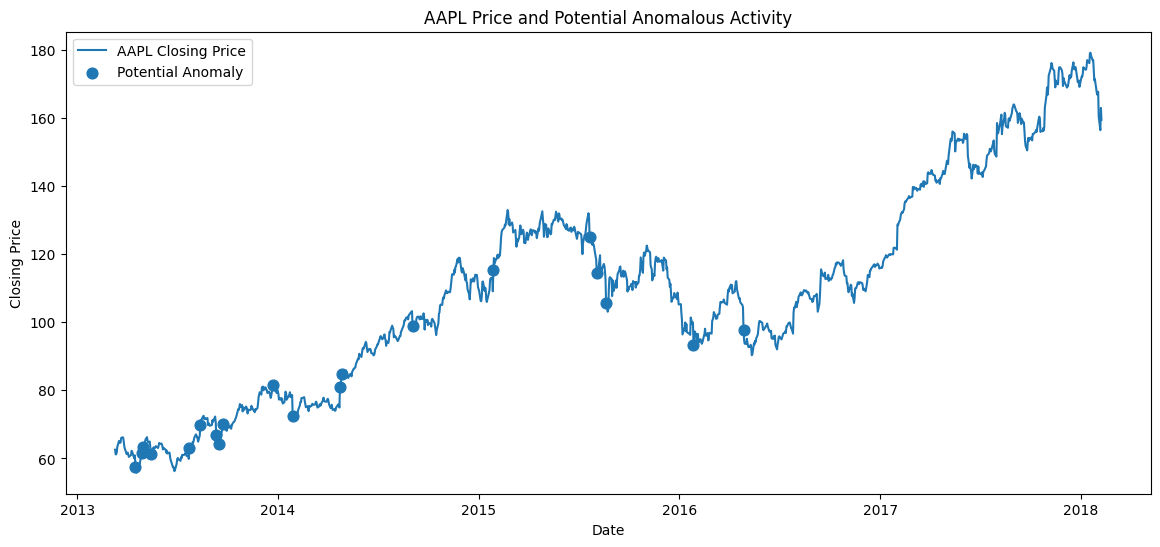

In [31]:
# Save anomaly detection graph

plt.figure(figsize=(14, 6))

plt.plot(
    aapl_features["date"],
    aapl_features["close"],
    label="AAPL Closing Price"
)

plt.scatter(
    anomalies["date"],
    anomalies["close"],
    marker="o",
    s=60,
    label="Potential Anomaly"
)

plt.title("AAPL Price and Potential Anomalous Activity")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.savefig(
    "/content/results/anomaly_detection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()